Mounted at /content/drive


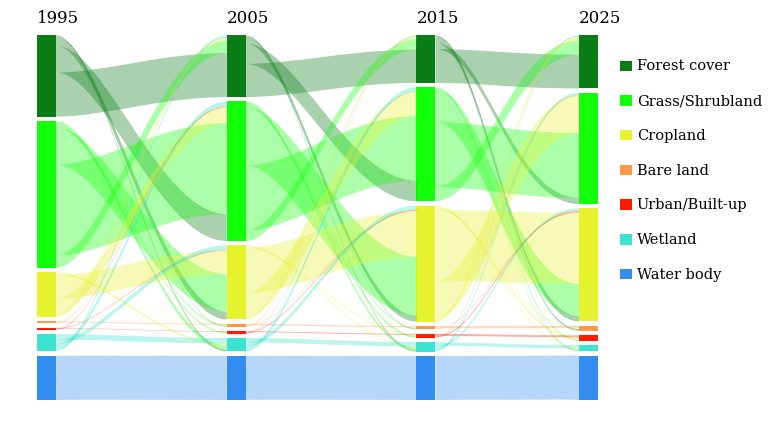

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

plt.rcParams['font.family'] = 'serif'

lulc_path = '/content/drive/MyDrive/tanganyikabasinbdi/'

r1995 = rasterio.open(lulc_path + '1995.tif')
r2005 = rasterio.open(lulc_path + '2005.tif')
r2015 = rasterio.open(lulc_path + '2015.tif')
r2025 = rasterio.open(lulc_path + '2025.tif')

a1995 = r1995.read(1).astype(float)
a2005 = r2005.read(1).astype(float)
a2015 = r2015.read(1).astype(float)
a2025 = r2025.read(1).astype(float)

nodata_values = [255, -9999]

for nd in nodata_values:

    a1995[a1995 == nd] = np.nan
    a2005[a2005 == nd] = np.nan
    a2015[a2015 == nd] = np.nan
    a2025[a2025 == nd] = np.nan

classes = {
    0: "Forest cover",
    1: "Grass/Shrubland",
    2: "Cropland",
    3: "Bare land",
    4: "Urban/Built-up",
    5: "Wetland",
    6: "Water body"
}

colors = {
    "Forest cover": "#0A7D17",
    "Grass/Shrubland": "#11FF09",
    "Cropland": "#E6F22E",
    "Bare land": "#FF9746",
    "Urban/Built-up": "#FF1A00",
    "Wetland": "#3BE3D0",
    "Water body": "#338DF1"
}

class_order = [
    "Forest cover",
    "Grass/Shrubland",
    "Cropland",
    "Bare land",
    "Urban/Built-up",
    "Wetland",
    "Water body"
]

years = [1995, 2005, 2015, 2025]

arrays = {
    1995: a1995,
    2005: a2005,
    2015: a2015,
    2025: a2025
}

pixel_area_km2 = (30 * 30) / 1e6

area_data = []

for year in years:

    arr = arrays[year]

    unique, counts = np.unique(
        arr[~np.isnan(arr)],
        return_counts=True
    )

    for u, c in zip(unique, counts):

        u = int(u)

        if u in classes:

            area_data.append({
                "Year": year,
                "Class": classes[u],
                "Area_km2": c * pixel_area_km2
            })

area_df = pd.DataFrame(area_data)

area_table = (
    area_df
    .pivot(
        index='Class',
        columns='Year',
        values='Area_km2'
    )
    .reindex(class_order)
)

area_table["Net_Change_1995_2025"] = (
    area_table[2025] - area_table[1995]
)

area_table["Percent_Change"] = (
    (
        area_table[2025] - area_table[1995]
    ) / area_table[1995]
) * 100

area_table = area_table.round(2)

area_table.to_csv(
    '/content/LULC_Area_Statistics.csv'
)

def transition_table(arr1, arr2, y1, y2):

    df = pd.DataFrame({
        "From": arr1.flatten(),
        "To": arr2.flatten()
    })

    df = df.dropna()

    tr = (
        df.groupby(["From", "To"])
        .size()
        .reset_index(name="Pixels")
    )

    tr["Area_km2"] = (
        tr["Pixels"] * pixel_area_km2
    )

    tr["From_Class"] = (
        tr["From"].map(classes)
    )

    tr["To_Class"] = (
        tr["To"].map(classes)
    )

    tr["Period"] = (
        str(y1) + "-" + str(y2)
    )

    tr = tr[
        [
            "Period",
            "From_Class",
            "To_Class",
            "Area_km2"
        ]
    ]

    tr = tr.rename(
        columns={
            "From_Class": "From",
            "To_Class": "To"
        }
    )

    return tr

t1 = transition_table(a1995, a2005, 1995, 2005)
t2 = transition_table(a2005, a2015, 2005, 2015)
t3 = transition_table(a2015, a2025, 2015, 2025)

transition_df = pd.concat(
    [t1, t2, t3],
    ignore_index=True
)

transition_df["Area_km2"] = (
    transition_df["Area_km2"]
    .round(2)
)

transition_df.to_csv(
    '/content/LULC_Transition_Table.csv',
    index=False
)

fig, ax = plt.subplots(figsize=(7.48, 4.34))

ax.set_xlim(0.02, 1.08)
ax.set_ylim(0.02, 0.98)
ax.axis('off')

x_positions = {
    1995: 0.06,
    2005: 0.34,
    2015: 0.62,
    2025: 0.86
}

bar_width = 0.028

node_positions = {}

for year in years:

    temp = (
        area_df[area_df["Year"] == year]
        .set_index("Class")
        .reindex(class_order)
        .reset_index()
    )

    total = temp["Area_km2"].sum()

    y = 0.92

    for i, row in temp.iterrows():

        h = (
            row["Area_km2"] / total
        ) * 0.78

        y0 = y - h

        node_positions[
            (year, row["Class"])
        ] = {
            "x": x_positions[year],
            "y0": y0,
            "y1": y
        }

        ax.fill_between(
            [x_positions[year], x_positions[year] + bar_width],
            y0,
            y,
            color=colors[row["Class"]],
            linewidth=0
        )

        y = y0 - 0.01

def flow_patch(
    x0,
    y0_low,
    y0_high,
    x1,
    y1_low,
    y1_high,
    color,
    alpha=0.35
):

    verts = [

        (x0 + bar_width, y0_low),

        (x0 + 0.1, y0_low),
        (x1 - 0.1, y1_low),
        (x1, y1_low),

        (x1, y1_high),

        (x1 - 0.1, y1_high),
        (x0 + 0.1, y0_high),
        (x0 + bar_width, y0_high),

        (x0 + bar_width, y0_low)

    ]

    codes = [

        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CLOSEPOLY
    ]

    path = Path(verts, codes)

    patch = PathPatch(
        path,
        facecolor=color,
        edgecolor='none',
        alpha=0.35
    )

    ax.add_patch(patch)

def raw_transition(arr1, arr2):

    df = pd.DataFrame({
        "from": arr1.flatten(),
        "to": arr2.flatten()
    })

    df = df.dropna()

    tr = (
        df.groupby(["from", "to"])
        .size()
        .reset_index(name="count")
    )

    tr["area"] = (
        tr["count"] * pixel_area_km2
    )

    tr["from_class"] = (
        tr["from"].map(classes)
    )

    tr["to_class"] = (
        tr["to"].map(classes)
    )

    tr = tr.dropna()

    return tr

tr1 = raw_transition(a1995, a2005)
tr2 = raw_transition(a2005, a2015)
tr3 = raw_transition(a2015, a2025)

def draw_flows(tr, year1, year2):

    source_offsets = {}
    target_offsets = {}

    for cls in class_order:

        source_offsets[cls] = (
            node_positions[(year1, cls)]["y0"]
        )

        target_offsets[cls] = (
            node_positions[(year2, cls)]["y0"]
        )

    total_area = (
        area_df[
            area_df["Year"] == year1
        ]["Area_km2"].sum()
    )

    for i, row in tr.iterrows():

        fc = row["from_class"]
        tc = row["to_class"]

        if pd.isna(fc) or pd.isna(tc):
            continue

        source_height = (
            row["area"] / total_area
        ) * 0.78

        target_height = source_height

        sy0 = source_offsets[fc]
        sy1 = sy0 + source_height

        ty0 = target_offsets[tc]
        ty1 = ty0 + target_height

        flow_patch(
            x_positions[year1],
            sy0,
            sy1,
            x_positions[year2],
            ty0,
            ty1,
            colors[fc]
        )

        source_offsets[fc] += source_height
        target_offsets[tc] += target_height

draw_flows(tr1, 1995, 2005)
draw_flows(tr2, 2005, 2015)
draw_flows(tr3, 2015, 2025)

ax.text(
    0.06,
    0.95,
    "1995",
    fontsize=12
)

ax.text(
    0.34,
    0.95,
    "2005",
    fontsize=12
)

ax.text(
    0.62,
    0.95,
    "2015",
    fontsize=12
)

ax.text(
    0.86,
    0.95,
    "2025",
    fontsize=12
)

legend_x = 0.92
legend_y = 0.85
legend_space = 0.08

for i, cls in enumerate(class_order):

    y_pos = legend_y - (i * legend_space)

    ax.fill_between(
        [legend_x, legend_x + 0.018],
        y_pos - 0.012,
        y_pos + 0.012,
        color=colors[cls],
        linewidth=0
    )

    ax.text(
        legend_x + 0.025,
        y_pos,
        cls,
        fontsize=10.5,
        color='black',
        va='center'
    )

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.98,
    bottom=0.02
)

plt.savefig(
    '/content/LULC_Sankey.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.02
)

plt.show()